# Ping Pong Ball Prediction Using Transfer Learning:

Inputs:
- x y z (frame 1)
- x y z (frame 2)
- x y z (frame 3)
- x y z (frame 4)
- dt12
- dt23
- dt34

Outputs:
- x y z (interception)
- vx vy vz
- t_hit
- is_reachable



## Importing the Libraries

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

### Importing the Dataset

In [2]:
dataset = pd.read_csv('../learning_data/synthetic_data/synthetic_intercept_dataset.csv')

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   x1                     10000 non-null  float64
 1   y1                     10000 non-null  float64
 2   z1                     10000 non-null  float64
 3   x2                     10000 non-null  float64
 4   y2                     10000 non-null  float64
 5   z2                     10000 non-null  float64
 6   x3                     10000 non-null  float64
 7   y3                     10000 non-null  float64
 8   z3                     10000 non-null  float64
 9   x4                     10000 non-null  float64
 10  y4                     10000 non-null  float64
 11  z4                     10000 non-null  float64
 12  dt12                   10000 non-null  float64
 13  dt23                   10000 non-null  float64
 14  dt34                   10000 non-null  float64
 15  x_h

In [4]:
dataset.describe()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,bounces_before_hit,has_bounce_before_hit,intercept_valid,x0,y0,z0,vx0,vy0,vz0,gravity_z_mm_s2
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.0,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,-7.446524,2592.658342,-802.426117,-7.230343,2524.401243,-831.822478,-6.981197,2456.311557,-858.414933,-6.630498,...,1.156100,0.957700,1.0,-7.491467,2592.632267,-802.399696,19.397081,-4523.845495,-2044.968158,-9808.109108
std,617.895759,376.851726,201.076098,596.290240,398.515104,199.177621,575.554119,420.788533,193.691200,555.847353,...,0.465139,0.201283,0.0,617.800108,376.774906,200.900408,2065.644357,1839.807004,1782.028624,296.049691
min,-1062.500000,1940.000000,-1150.740000,-1068.514700,1757.374697,-1174.777218,-1082.284917,1586.891170,-1170.380456,-1078.704177,...,0.000000,0.000000,1.0,-1062.381138,1940.247379,-1150.706953,-5139.502368,-10000.000000,-5522.688303,-10874.869530
25%,-548.004055,2264.198399,-977.125873,-528.294165,2177.969243,-1008.794408,-509.910512,2093.600217,-1037.876632,-491.235994,...,1.000000,1.000000,1.0,-545.621622,2264.566869,-974.612458,-1452.658113,-5753.445844,-3576.724927,-10009.931075
50%,-11.958664,2598.520283,-803.549198,-14.863201,2527.091758,-834.881187,-12.380764,2460.916726,-868.210773,-13.483849,...,1.000000,1.000000,1.0,-12.178135,2597.530273,-803.123315,-11.985088,-4242.123295,-2084.534559,-9807.532502
75%,528.945886,2925.960485,-630.885863,509.513279,2874.712261,-660.673955,490.047715,2825.990110,-695.550558,472.652952,...,1.000000,1.000000,1.0,526.848933,2927.145024,-630.183900,1519.207435,-3088.240000,-607.111141,-9611.093107
max,1062.500000,3240.000000,-450.740000,1084.655982,3240.999888,-397.215739,1065.922882,3209.632930,-390.680577,1061.299312,...,2.000000,1.000000,1.0,1062.462788,3239.552402,-450.776159,5207.320759,-772.200996,2360.905866,-8756.161802


### Pre-Processing

### Separating the Input and Outputs

In [5]:
x = dataset.iloc[:, :15]
y = dataset.iloc[:, 15:-11]

In [6]:
# View the inputs
print(x)

               x1           y1           z1          x2           y2  \
0     -134.725456  3058.889278  -661.456858  -77.657672  3009.264032   
1     -590.247408  2809.676972  -845.501112 -543.995894  2730.029537   
2     -463.311121  2326.379557  -686.164851 -441.115845  2255.991167   
3     -396.662303  2688.004543 -1030.049828 -388.810251  2638.490365   
4    -1026.184504  3017.148022  -521.234071 -984.531658  2995.671064   
...           ...          ...          ...         ...          ...   
9995  -822.447033  3130.626593  -575.825666 -825.981833  3110.912930   
9996   211.258831  2274.484361 -1091.660291  225.155181  2198.470936   
9997 -1013.586026  2287.099539  -871.531877 -961.392201  2179.646769   
9998   748.384321  2161.454119  -661.099567  755.952342  2092.684756   
9999  -749.278380  2330.828443  -776.797267 -752.644679  2228.737746   

               z2          x3           y3           z3          x4  \
0     -641.671706  -33.379228  2978.006245  -646.305425   20.290

In [7]:
# View the outputs
print(y)

            x_hit        y_hit        z_hit       vx_hit       vy_hit  \
0     1371.275360  1931.111771  -750.207075  2680.640491 -2009.045581   
1      672.122875   339.503341  -847.070708  2408.539439 -4752.413176   
2      430.631575   258.957866  -620.181008  2594.755955 -5978.881216   
3      653.011371   304.645200  -904.550381  2266.709670 -5081.574979   
4     1211.472546  1626.324388  -632.992379  2652.436758 -1652.208469   
...           ...          ...          ...          ...          ...   
9995  -369.138209   -50.758923  -910.781517   404.419629 -2857.154728   
9996   736.145062   202.163632  -992.696229  1627.465175 -6253.700143   
9997    45.149661   199.408229  -346.387408  3450.977619 -6829.947308   
9998   724.605456   -58.344907 -1018.699286   -54.788885 -5643.325693   
9999  -786.757775    87.820239  -639.726259  -129.467084 -7272.549227   

           vz_hit     t_hit  
0     1473.393321  0.505366  
1     -511.716486  0.481770  
2     1910.078693  0.301211  
3  

In [8]:
x = x.values
y = y.values

### Splitting the Dataset into the Training set and Test set

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1) Build reachability vector from your full dataset
# (change column name if needed)
r = dataset["is_reachable"].to_numpy().astype(int)

# 2) Split x, y, and r together (important)
x_train, x_test, y_train, y_test, r_train, r_test = train_test_split(
    x, y, r,
    test_size=0.05,
    random_state=1,
    stratify=r   # recommended
)

# 3) Keep full test copy
x_test_all = x_test.copy()
y_test_all = y_test.copy()

# 4) Reachable-only adjusted test set
mask_reach = (r_test == 1)
x_test_reach = x_test_all[mask_reach].copy()
y_test_reach = y_test_all[mask_reach].copy()


In [10]:
print(x_train.shape)
print(x_test_all.shape)
print(x_test_reach.shape)
print(y_train.shape)
print(y_test_all.shape)
print(y_test_reach.shape)

(9500, 15)
(500, 15)
(116, 15)
(9500, 7)
(500, 7)
(116, 7)


### Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

scx = StandardScaler()
scy = StandardScaler()

x_train = scx.fit_transform(x_train)
x_test_all = scx.transform(x_test_all)
x_test_reach = scx.transform(x_test_reach)

y_train = scy.fit_transform((y_train))
y_test_all = scy.transform((y_test_all))
y_test_reach = scy.transform((y_test_reach))

## The ANN Model Initialization

In [12]:
ball_predictor = tf.keras.models.Sequential()

### Constructing the Model

In [13]:
ball_predictor.add(tf.keras.layers.Dense(units=15, activation='relu')) # 15 input features
ball_predictor.add(tf.keras.layers.Dense(units=30, activation='relu')) # hiddel layer 1
ball_predictor.add(tf.keras.layers.Dense(units=15, activation='relu')) # hidden layer 3
ball_predictor.add(tf.keras.layers.Dense(units=7, activation='linear')) # 7

In [14]:
ball_predictor.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_squared_error'])

### Training

In [15]:
p1 = ball_predictor.fit(x_train, y_train, validation_split=0.2, batch_size = 32, epochs = 300,verbose=1)

Epoch 1/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8537 - mean_squared_error: 0.8537 - val_loss: 0.7118 - val_mean_squared_error: 0.7118
Epoch 2/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6851 - mean_squared_error: 0.6851 - val_loss: 0.6675 - val_mean_squared_error: 0.6675
Epoch 3/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6521 - mean_squared_error: 0.6521 - val_loss: 0.6373 - val_mean_squared_error: 0.6373
Epoch 4/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6229 - mean_squared_error: 0.6229 - val_loss: 0.6082 - val_mean_squared_error: 0.6082
Epoch 5/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5920 - mean_squared_error: 0.5920 - val_loss: 0.5735 - val_mean_squared_error: 0.5735
Epoch 6/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5553 - mean_squared_error: 0.5553 - val_loss: 0.5328 - val_mean_squared_error: 0.5328
Epoch 7/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4875 - mean_squared_error: 0.4875 - val_los

### Learning Curves

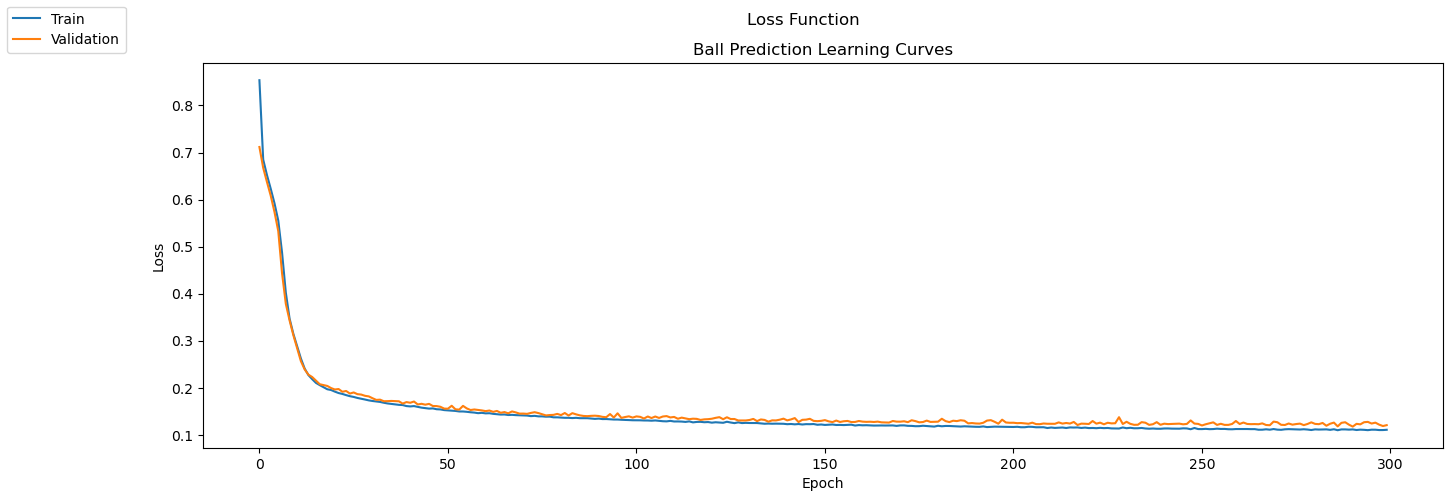

In [16]:
fig, axs = plt.subplots(figsize=(16,5))
fig.suptitle('Loss Function')

axs.plot(p1.history['loss'])
axs.plot(p1.history['val_loss'])
axs.set_title("Ball Prediction Learning Curves")
axs.set(xlabel='Epoch', ylabel='Loss')

fig.legend(labels=['Train', 'Validation'], loc="upper left")
plt.show()

In [17]:
# def eval_regression(name, y_true, y_pred):
#     mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred, multioutput='raw_values'))
#     print(f"\n{name}")
#     print("MAE per output:", mae)
#     print("RMSE per output:", rmse)

# # If y is scaled, inverse-transform both y_true and y_pred before metrics.
# y_pred_all = ball_predictor.predict(x_test_all)
# y_pred_reach = ball_predictor.predict(x_test_reach)

# # Example for scaled targets:
# # y_pred_all = scy.inverse_transform(y_pred_all); y_test_all_eval = scy.inverse_transform(y_test_all)
# # y_pred_reach = scy.inverse_transform(y_pred_reach); y_test_reach_eval = scy.inverse_transform(y_test_reach)

# eval_regression("All test shots", y_test_all, y_pred_all)
# eval_regression("Reachable-only test shots", y_test_reach, y_pred_reach)

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

target_names = ["x_hit", "y_hit", "z_hit", "vx_hit", "vy_hit", "vz_hit", "t_hit"]
target_units = ["mm", "mm", "mm", "mm/s", "mm/s", "mm/s", "ms"]

def eval_with_units(name, model, x_eval, y_eval, y_scaler, y_is_scaled=True, t_hit_in_seconds=True):
    y_pred = model.predict(x_eval, verbose=0)

    # Convert to physical units exactly once
    if y_is_scaled:
        assert y_eval.shape[1] == y_scaler.n_features_in_ == len(target_names)
        y_true_u = y_scaler.inverse_transform(y_eval)
        y_pred_u = y_scaler.inverse_transform(y_pred)
    else:
        y_true_u = y_eval
        y_pred_u = y_pred

    err = y_pred_u - y_true_u
    abs_err = np.abs(err)

    mae = mean_absolute_error(y_true_u, y_pred_u, multioutput="raw_values")
    rmse = np.sqrt(mean_squared_error(y_true_u, y_pred_u, multioutput="raw_values"))
    std_abs = abs_err.std(axis=0)

    # Convert t_hit to ms for reporting (only if stored in seconds)
    if t_hit_in_seconds:
        i = target_names.index("t_hit")
        mae[i] *= 1000.0
        rmse[i] *= 1000.0
        std_abs[i] *= 1000.0

    report = pd.DataFrame({
        "target": target_names,
        "unit": target_units,
        "MAE": mae,
        "RMSE": rmse,
        "STD_abs_error": std_abs,
    })

    print(f"\n{name}")
    print(report.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

# Run both:
eval_with_units("All test shots", ball_predictor, x_test_all, y_test_all, scy, y_is_scaled=True, t_hit_in_seconds=True)
eval_with_units("Reachable-only test shots", ball_predictor, x_test_reach, y_test_reach, scy, y_is_scaled=True, t_hit_in_seconds=True)




All test shots
target unit     MAE      RMSE  STD_abs_error
 x_hit   mm 118.303   156.493        102.443
 y_hit   mm 128.133   176.385        121.217
 z_hit   mm 103.731   139.599         93.422
vx_hit mm/s 226.761   283.528        170.200
vy_hit mm/s 241.057   309.648        194.353
vz_hit mm/s 862.373 1,281.327        947.688
 t_hit   ms  45.332    66.455         48.594

Reachable-only test shots
target unit       MAE      RMSE  STD_abs_error
 x_hit   mm   112.118   143.533         89.618
 y_hit   mm   131.530   175.996        116.937
 z_hit   mm    96.625   138.408         99.099
vx_hit mm/s   241.973   295.562        169.724
vy_hit mm/s   271.190   331.608        190.839
vz_hit mm/s 1,131.758 1,772.607      1,364.280
 t_hit   ms    47.728    67.808         48.167


In [18]:
# Verification 
train_std = scy.scale_ 
rmse_sigma = np.sqrt(0.1084)   # val_mse from curve, e.g. 0.1151
rmse_units = rmse_sigma * train_std

print(rmse_units)


[2.48636889e+02 1.77037428e+02 1.17619435e+02 6.81252147e+02
 6.06666025e+02 7.20216283e+02 9.25594607e-02]


## Loading the Matched Synthetic Dataset (Transfer Learning)

In [21]:
matched_dataset = pd.read_csv('../learning_data/synthetic_matched_data/synthetic_matched_dataset.csv')
matched_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   x1                     10000 non-null  float64
 1   y1                     10000 non-null  float64
 2   z1                     10000 non-null  float64
 3   x2                     10000 non-null  float64
 4   y2                     10000 non-null  float64
 5   z2                     10000 non-null  float64
 6   x3                     10000 non-null  float64
 7   y3                     10000 non-null  float64
 8   z3                     10000 non-null  float64
 9   x4                     10000 non-null  float64
 10  y4                     10000 non-null  float64
 11  z4                     10000 non-null  float64
 12  dt12                   10000 non-null  float64
 13  dt23                   10000 non-null  float64
 14  dt34                   10000 non-null  float64
 15  x_h

In [22]:
x_matched = matched_dataset.iloc[:, :15]
y_matched = matched_dataset.iloc[:, 15:-11]


# View the inputs
print(x_matched)
print(y_matched)

x_matched = x_matched.values
y_matched = y_matched.values

              x1           y1           z1          x2           y2  \
0     323.584807  2699.616386  -791.351576  312.387931  2655.585742   
1       4.002104  2543.403984  -691.731292  -17.300255  2452.365308   
2    -281.055862  2618.294362 -1008.380501 -267.684669  2547.361264   
3    -258.737518  2485.995832 -1065.542642 -264.919644  2426.566822   
4     -91.419849  2739.225555  -495.799465  -89.426084  2696.096015   
...          ...          ...          ...         ...          ...   
9995  -27.780133  2573.997800  -486.307230  -18.261295  2459.539324   
9996  154.952661  2472.369146  -986.345042  153.305531  2387.939091   
9997   81.701211  2672.812861  -723.367771   85.805068  2623.416986   
9998  669.398159  2665.395213  -520.975314  651.437745  2591.797811   
9999  200.016784  2495.237572  -709.530542  191.188423  2378.244418   

               z2          x3           y3           z3          x4  \
0     -816.072073  309.372600  2626.036730  -827.378008  296.605266   
1    

In [23]:
#Split input and output x, y
x_matched_train, x_matched_test, y_matched_train, y_matched_test= train_test_split(
    x_matched, y_matched,
    test_size=0.1,
    random_state=1
)

In [24]:
print(x_matched_train.shape)
print(x_matched_test.shape)
print(y_matched_train.shape)
print(y_matched_test.shape)

x_matched_train_s = scx.transform(x_matched_train)
x_matched_test_s = scx.transform(x_matched_test)
y_matched_train_s = scy.transform(y_matched_train)
y_matched_test_s = scy.transform(y_matched_test)

(9000, 15)
(1000, 15)
(9000, 7)
(1000, 7)


In [25]:
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Start from synthetic-pretrained weights
transfer_model_matched = tf.keras.models.clone_model(ball_predictor)
transfer_model_matched.set_weights(ball_predictor.get_weights())

transfer_model_matched.compile(
    loss="mean_squared_error",
    optimizer=Adam(learning_rate=1e-3),
    metrics=["mean_squared_error"]
)

history_matched = transfer_model_matched.fit(
    x_matched_train_s, y_matched_train_s,
    validation_split=0.2,
    epochs=100,
    verbose=1
)

Epoch 1/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0859 - mean_squared_error: 0.0859 - val_loss: 0.0823 - val_mean_squared_error: 0.0823
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0804 - mean_squared_error: 0.0804 - val_loss: 0.0783 - val_mean_squared_error: 0.0783
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0776 - mean_squared_error: 0.0776 - val_loss: 0.0825 - val_mean_squared_error: 0.0825
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0760 - mean_squared_error: 0.0760 - val_loss: 0.0771 - val_mean_squared_error: 0.0771
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0749 - mean_squared_error: 0.0749 - val_loss: 0.0751 - val_mean_squared_error: 0.0751
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0736 - mean_squared_error: 0.0736 - val_loss: 0.0788 - val_mean_squared_error: 0.0788
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0722 - mean_squared_error: 0.0722 - val_los

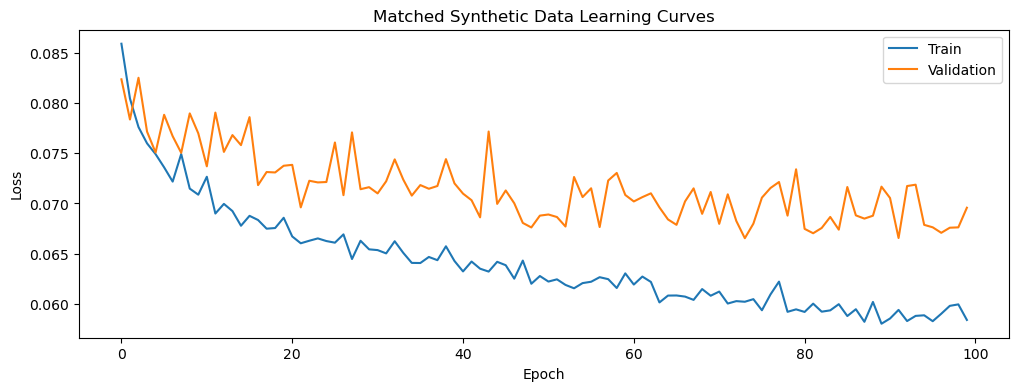

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(history_matched.history["loss"], label="Train")
ax.plot(history_matched.history["val_loss"], label="Validation")
ax.set_title("Matched Synthetic Data Learning Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.show()

In [27]:
eval_with_units(
    "Matched Data Transfer Model",
    transfer_model_matched,
    x_matched_test_s,
    y_matched_test_s,
    scy,
    y_is_scaled=True,
    t_hit_in_seconds=True
)


Matched Data Transfer Model
target unit     MAE      RMSE  STD_abs_error
 x_hit   mm  72.071    95.316         62.378
 y_hit   mm  92.775   126.256         85.635
 z_hit   mm  40.514    50.038         29.367
vx_hit mm/s 115.825   147.511         91.345
vy_hit mm/s 163.313   213.453        137.444
vz_hit mm/s 653.660 1,163.209        962.177
 t_hit   ms  29.821    44.632         33.207


## Loading the Real Dataset (Transfer Learning)

In [66]:
real_dataset = pd.read_csv('../learning_data/real_data/real_transfer_dataset_clean.csv')
real_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sample_id           80 non-null     int64  
 1   captured_at         80 non-null     object 
 2   x1                  80 non-null     float64
 3   y1                  80 non-null     float64
 4   z1                  80 non-null     float64
 5   x2                  80 non-null     float64
 6   y2                  80 non-null     float64
 7   z2                  80 non-null     float64
 8   x3                  80 non-null     float64
 9   y3                  80 non-null     float64
 10  z3                  80 non-null     float64
 11  x4                  80 non-null     float64
 12  y4                  80 non-null     float64
 13  z4                  80 non-null     float64
 14  dt12                80 non-null     float64
 15  dt23                80 non-null     float64
 16  dt34      

In [67]:
real_dataset.describe()

,sample_id,x1,y1,z1,x2,y2,z2,x3,y3,z3,...,x_hit,y_hit,z_hit,vx_hit,vy_hit,vz_hit,t_hit,is_reachable,intercept_valid,bounces_before_hit
count,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,...,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.0,80.0,80.000000
mean,47.125000,126.612093,2591.449725,-761.791921,126.761238,2513.987849,-775.495131,125.432742,2436.478162,-791.381096,...,76.342559,46.575018,-907.682583,-42.884910,-2385.960030,-278.552511,0.741691,1.0,1.0,1.125000
std,26.451472,271.347111,62.279668,171.448800,266.668826,67.252022,184.012954,261.782134,72.276213,195.976097,...,295.248039,97.102697,66.570062,330.544937,652.814734,1090.013869,0.183824,0.0,0.0,0.401737
min,1.000000,-371.352903,2474.123740,-1076.785318,-360.185295,2379.060989,-1110.802514,-360.406864,2286.534796,-1124.900432,...,-701.947682,-328.227102,-1019.507745,-1022.033907,-4597.915522,-3011.290991,0.382032,1.0,1.0,0.000000
25%,25.750000,-72.950039,2546.485334,-909.981788,-78.284393,2466.671439,-936.163130,-78.106019,2383.768672,-964.885410,...,-99.657641,-1.394730,-951.354162,-233.344772,-2767.130983,-1165.435303,0.621700,1.0,1.0,1.000000
50%,47.500000,109.521076,2579.879193,-760.515730,106.493038,2504.388456,-781.181150,103.027548,2431.891453,-800.763315,...,72.666277,27.231741,-907.160676,-27.869435,-2341.086691,-462.040608,0.718802,1.0,1.0,1.000000
75%,70.250000,309.993736,2627.887972,-619.762516,295.954137,2549.081834,-621.037727,281.874577,2481.585183,-626.871453,...,286.098751,82.785845,-860.487597,140.878215,-1914.624061,553.084686,0.847522,1.0,1.0,1.000000
max,91.000000,711.471532,2717.651305,-457.089021,698.851431,2661.683643,-454.160729,685.853714,2614.600661,-443.300851,...,701.506781,371.290518,-800.151669,874.429531,-1232.469961,1742.177354,1.241465,1.0,1.0,2.000000


### Pre-Processing the Real Dataset

In [68]:
x_real = real_dataset.iloc[:, 2:17]
y_real = real_dataset.iloc[:, 17:-3]

In [69]:
# View the inputs
print(x_real)

            x1           y1           z1          x2           y2  \
0   -93.085669  2546.231986  -918.175721  -66.675214  2465.409487   
1   253.280832  2618.434667  -887.696273  243.456673  2530.710133   
2   138.276373  2591.150386 -1007.428495  142.696882  2513.572280   
3    -4.816868  2545.514276  -862.061582   -0.465775  2463.644181   
4  -185.596759  2503.058353  -838.394090 -198.870946  2411.186734   
..         ...          ...          ...         ...          ...   
75  456.970889  2695.859462  -902.438977  458.953010  2631.602516   
76  -86.394866  2513.386321  -535.765480  -90.484254  2438.153943   
77  -69.582993  2546.569783  -555.203392  -89.055443  2467.092089   
78  109.369917  2590.155205  -744.746984  100.909601  2520.597169   
79  -83.051176  2533.622961  -547.087329  -90.578093  2445.765975   

             z2          x3           y3           z3          x4  \
0   -950.696625  -57.019999  2379.771476  -990.993770  -37.048924   
1   -922.622107  236.047704  2443

In [70]:
# View the inputs
print(y_real)

         x_hit       y_hit       z_hit      vx_hit       vy_hit       vz_hit  \
0   658.431426  186.145714 -892.452886  728.802670 -2081.964186   624.825909   
1   -33.169466  -23.127627 -949.963944 -276.611923 -2516.869388  1325.659844   
2   239.592959   12.987940 -923.123788   85.363122 -2191.648501  -780.166456   
3   405.096305   74.761886 -858.717278  341.693955 -2026.351570   331.536463   
4  -170.381534    1.371401 -896.207069  -10.085315 -2120.661508   467.959804   
..         ...         ...         ...         ...          ...          ...   
75  162.943001   10.345789 -932.164946 -215.711811 -1882.669877 -1260.136794   
76  -24.533740  -24.228500 -857.426613   61.761078 -2458.207609 -1405.678353   
77 -560.835984   87.400316 -821.190985 -535.798211 -2702.894023 -1009.420577   
78  -24.829500   -1.411993 -903.120639  -64.742114 -2010.803678    -4.368281   
79 -114.990334 -143.724057 -804.079048  -38.620152 -2764.857334  -862.659817   

       t_hit  
0   0.721709  
1   0.663

In [71]:
x_real = x_real.values
y_real = y_real.values

### Splitting the Dataset into the Training set and Test set

In [72]:
#Split input and output x, y
x_real_train, x_real_test, y_real_train, y_real_test= train_test_split(
    x_real, y_real,
    test_size=0.2,
    random_state=1
)


In [73]:
print(x_real_train.shape)
print(x_real_test.shape)
print(y_real_train.shape)
print(y_real_test.shape)

(64, 15)
(16, 15)
(64, 7)
(16, 7)


### Scaling the real dataset

In [74]:
x_real_train_s = scx.transform(x_real_train)
x_real_test_s = scx.transform(x_real_test)
y_real_train_s = scy.transform(y_real_train)
y_real_test_s = scy.transform(y_real_test)

## Training the New Layers (Classification Layers)

In [75]:


# Start from synthetic-pretrained weights
transfer_model = tf.keras.models.clone_model(transfer_model_matched)
transfer_model.set_weights(transfer_model_matched.get_weights())

# Stage 1: freeze first 2 layers
for layer in transfer_model.layers[:2]:
    layer.trainable = False

transfer_model.compile(
    loss="mean_squared_error",
    optimizer=Adam(learning_rate=5e-4),
    metrics=["mean_squared_error"]
)

history_stage1 = transfer_model.fit(
    x_real_train_s, y_real_train_s,
    validation_split=0.2,
    epochs=300,
    verbose=1
)



Epoch 1/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step - loss: 0.5168 - mean_squared_error: 0.5168 - val_loss: 0.6233 - val_mean_squared_error: 0.6233
Epoch 2/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.4956 - mean_squared_error: 0.4956 - val_loss: 0.6066 - val_mean_squared_error: 0.6066
Epoch 3/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.4756 - mean_squared_error: 0.4756 - val_loss: 0.5880 - val_mean_squared_error: 0.5880
Epoch 4/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.4559 - mean_squared_error: 0.4559 - val_loss: 0.5684 - val_mean_squared_error: 0.5684
Epoch 5/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.4390 - mean_squared_error: 0.4390 - val_loss: 0.5494 - val_mean_squared_error: 0.5494
Epoch 6/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.4217 - mean_squared_error: 0.4217 - val_loss: 0.5321 - val_mean_squared_error: 0.5321
Epoch 7/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.4051 - mean_squared_error: 0.4051 - val_loss: 0.5146 - val_mean

## Stage 1 Validation Curve

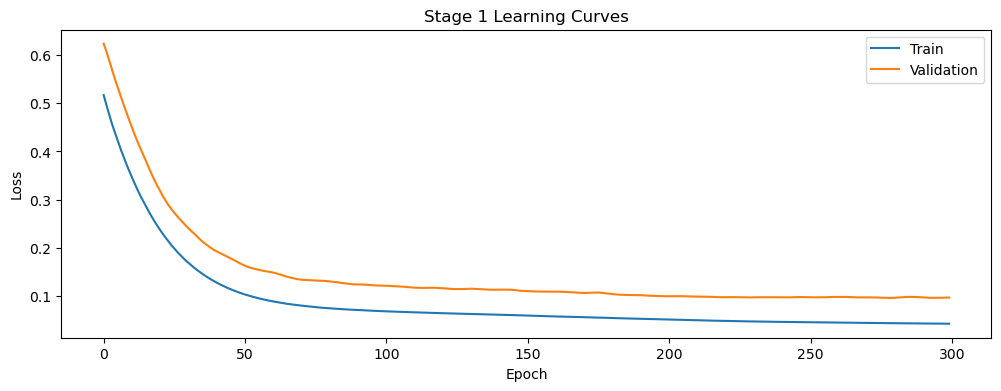

In [76]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(history_stage1.history["loss"], label="Train")
ax.plot(history_stage1.history["val_loss"], label="Validation")
ax.set_title("Stage 1 Learning Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.show()


In [77]:
eval_with_units(
    "Stage 1 Transfer Model - Real Test",
    transfer_model,
    x_real_test_s,
    y_real_test_s,
    scy,
    y_is_scaled=True,
    t_hit_in_seconds=True
)




Stage 1 Transfer Model - Real Test
target unit     MAE      RMSE  STD_abs_error
 x_hit   mm  89.689   111.971         67.032
 y_hit   mm  71.220    87.927         51.563
 z_hit   mm  52.567    63.885         36.304
vx_hit mm/s 109.959   127.842         65.211
vy_hit mm/s 287.765   379.910        248.038
vz_hit mm/s 904.615 1,120.373        660.989
 t_hit   ms  66.352    96.074         69.480


In [78]:

def snapshot_model(model):
    m = tf.keras.models.clone_model(model)
    m.set_weights(model.get_weights())
    return m

    
# --- run this RIGHT AFTER stage 1 training/eval ---
stage1_model = snapshot_model(transfer_model)
print("Saved stage1_model snapshot.")


Saved stage1_model snapshot.


In [79]:
# Stage 2: unfreeze all layers
for layer in transfer_model.layers:
    layer.trainable = True

transfer_model.compile(
    loss="mean_squared_error",
    optimizer=Adam(learning_rate=1e-5),
    metrics=["mean_squared_error"]
)

history_stage2 = transfer_model.fit(
    x_real_train_s, y_real_train_s,
    validation_split=0.2,
    epochs=100,
    verbose=1
)



Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - loss: 0.0428 - mean_squared_error: 0.0428 - val_loss: 0.0970 - val_mean_squared_error: 0.0970
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0427 - mean_squared_error: 0.0427 - val_loss: 0.0969 - val_mean_squared_error: 0.0969
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0427 - mean_squared_error: 0.0427 - val_loss: 0.0968 - val_mean_squared_error: 0.0968
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0427 - mean_squared_error: 0.0427 - val_loss: 0.0967 - val_mean_squared_error: 0.0967
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0426 - mean_squared_error: 0.0426 - val_loss: 0.0967 - val_mean_squared_error: 0.0967
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0426 - mean_squared_error: 0.0426 - val_loss: 0.0966 - val_mean_squared_error: 0.0966
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0426 - mean_squared_error: 0.0426 - val_loss: 0.0965 - val_mean

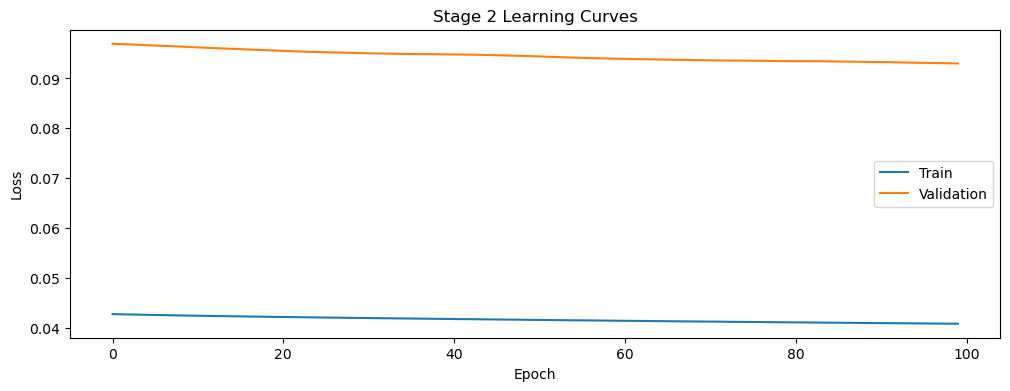

In [80]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(history_stage2.history["loss"], label="Train")
ax.plot(history_stage2.history["val_loss"], label="Validation")
ax.set_title("Stage 2 Learning Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.show()


In [81]:
eval_with_units(
    "Stage 2 Final Transfer Model - Real Test",
    transfer_model,
    x_real_test_s,
    y_real_test_s,
    scy,
    y_is_scaled=True,
    t_hit_in_seconds=True
)




Stage 2 Final Transfer Model - Real Test
target unit     MAE      RMSE  STD_abs_error
 x_hit   mm  89.810   111.497         66.074
 y_hit   mm  70.886    88.389         52.798
 z_hit   mm  54.090    64.932         35.923
vx_hit mm/s 109.689   127.454         64.906
vy_hit mm/s 271.799   379.902        265.425
vz_hit mm/s 913.991 1,173.439        735.920
 t_hit   ms  63.765    90.990         64.909


In [82]:
stage2_model = snapshot_model(transfer_model)
print("Saved stage2_model snapshot.")

# --- run once (any time after broad + matched are trained) ---
broad_model = snapshot_model(ball_predictor)
matched_model = snapshot_model(transfer_model_matched)
print("Saved broad_model and matched_model snapshots.")




Saved stage2_model snapshot.
Saved broad_model and matched_model snapshots.


In [83]:
# --- final comparison on real test set ---
eval_with_units("Broad model - Real Test",   broad_model,   x_real_test_s, y_real_test_s, scy, y_is_scaled=True, t_hit_in_seconds=True)
eval_with_units("Matched model - Real Test", matched_model, x_real_test_s, y_real_test_s, scy, y_is_scaled=True, t_hit_in_seconds=True)
eval_with_units("Stage 1 model - Real Test", stage1_model,  x_real_test_s, y_real_test_s, scy, y_is_scaled=True, t_hit_in_seconds=True)
eval_with_units("Stage 2 model - Real Test", stage2_model,  x_real_test_s, y_real_test_s, scy, y_is_scaled=True, t_hit_in_seconds=True)




Broad model - Real Test
target unit       MAE      RMSE  STD_abs_error
 x_hit   mm   101.521   120.799         65.466
 y_hit   mm    73.855    95.236         60.127
 z_hit   mm   134.365   171.608        106.750
vx_hit mm/s   283.452   354.458        212.827
vy_hit mm/s 2,433.662 2,475.295        452.076
vz_hit mm/s 1,368.216 1,632.484        890.499
 t_hit   ms   250.126   293.318        153.208

Matched model - Real Test
target unit       MAE      RMSE  STD_abs_error
 x_hit   mm    90.735   120.843         79.813
 y_hit   mm    90.237   113.841         69.405
 z_hit   mm    80.567    87.325         33.684
vx_hit mm/s   267.433   331.713        196.246
vy_hit mm/s 2,490.694 2,518.680        374.422
vz_hit mm/s 1,770.090 2,056.089      1,046.081
 t_hit   ms   241.094   277.055        136.504

Stage 1 model - Real Test
target unit     MAE      RMSE  STD_abs_error
 x_hit   mm  89.689   111.971         67.032
 y_hit   mm  71.220    87.927         51.563
 z_hit   mm  52.567    63.885     